# House Prices — 线性回归实战

**目标**：根据 79 个房屋特征，预测房价 `SalePrice`（连续数值）。

**技术栈**：Python + pandas + sklearn + seaborn，模型为线性回归家族（线性回归 / 岭回归 / 套索）。

---

## 运行步骤
1. 环境配置与可复现性设置
2. 数据加载与概览
3. 探索性数据分析（EDA）
4. 数据清洗与特征工程
5. 多重共线性检测（VIF）
6. 模型构建与选择（线性 / 岭 / 套索）
7. 模型评估与交叉验证
8. 预测并生成提交文件

## 1. 环境配置

In [57]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

warnings.filterwarnings("ignore")

# ---- 全局可复现性 ----
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- 展示设置 ----
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("环境配置完成")
print(f"当前工作目录: {os.getcwd()}")

环境配置完成
当前工作目录: e:\BaiduNetdiskDownload\Study_files\学习考证\Agent_Exercise\Kaggle_Competitions\Machine_learning\Linear_Regression


确认数据文件位置。数据已下载到 `house-prices-data/` 文件夹下。

In [58]:
DATA_DIR = "house-prices-data"
assert os.path.exists(DATA_DIR), f"数据目录不存在: {DATA_DIR}"
print("数据文件:", sorted(os.listdir(DATA_DIR)))

数据文件: ['data_description.txt', 'sample_submission.csv', 'test.csv', 'train.csv']


## 2. 数据加载与概览

In [59]:
# 读取训练集与测试集
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"训练集形状: {train.shape}")
print(f"测试集形状: {test.shape}")

# 保存测试集 Id，用于最终提交
test_ids = test["Id"].copy()

train.head()

训练集形状: (1460, 81)
测试集形状: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [60]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 3. 探索性数据分析（EDA）

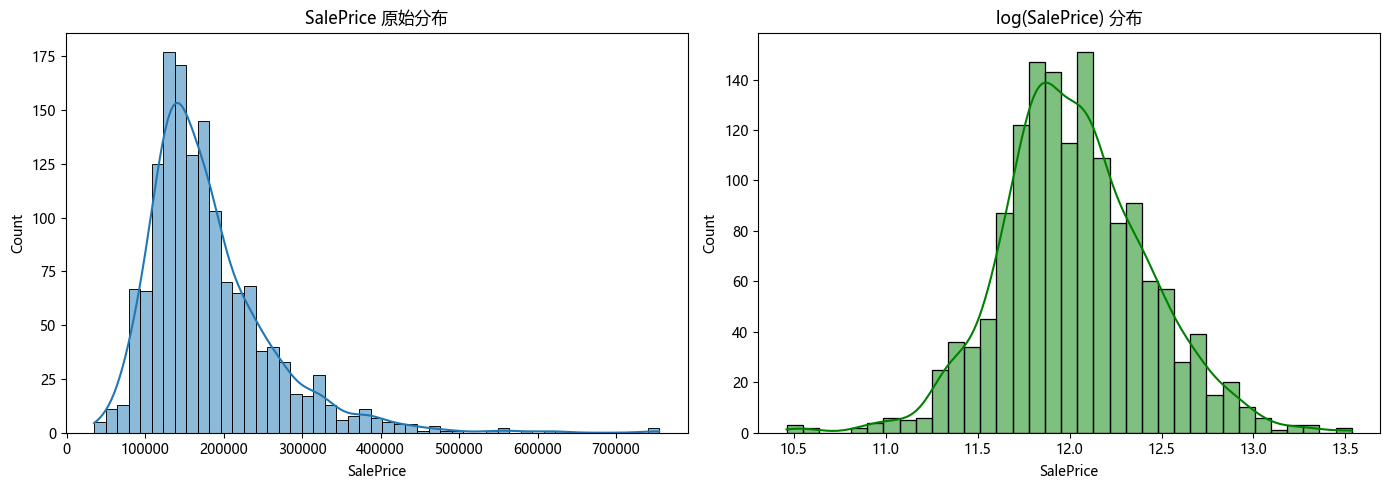

SalePrice 偏度（skewness）: 1.88


In [61]:
# ---- 目标变量 SalePrice 分布 ----
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice 原始分布")

# 观察经过 log 变换后的分布
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1], color="green")
axes[1].set_title("log(SalePrice) 分布")
plt.tight_layout()
plt.show()

print(f"SalePrice 偏度（skewness）: {stats.skew(train['SalePrice']):.2f}")

SalePrice 原始分布右偏严重，log(SalePrice) 分布接近正态
偏度远大于 0 → 右偏，后续需做 log 变换

In [62]:
# ---- 缺失值概览 ----
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

missing_pct = (missing_train / len(train) * 100).round(2)
pd.DataFrame({"缺失数量": missing_train, "缺失比例%": missing_pct})

,缺失数量,缺失比例%
PoolQC,1453,99.5200
MiscFeature,1406,96.3000
Alley,1369,93.7700
Fence,1179,80.7500
MasVnrType,872,59.7300
FireplaceQu,690,47.2600
LotFrontage,259,17.7400
GarageType,81,5.5500
GarageYrBlt,81,5.5500
GarageFinish,81,5.5500


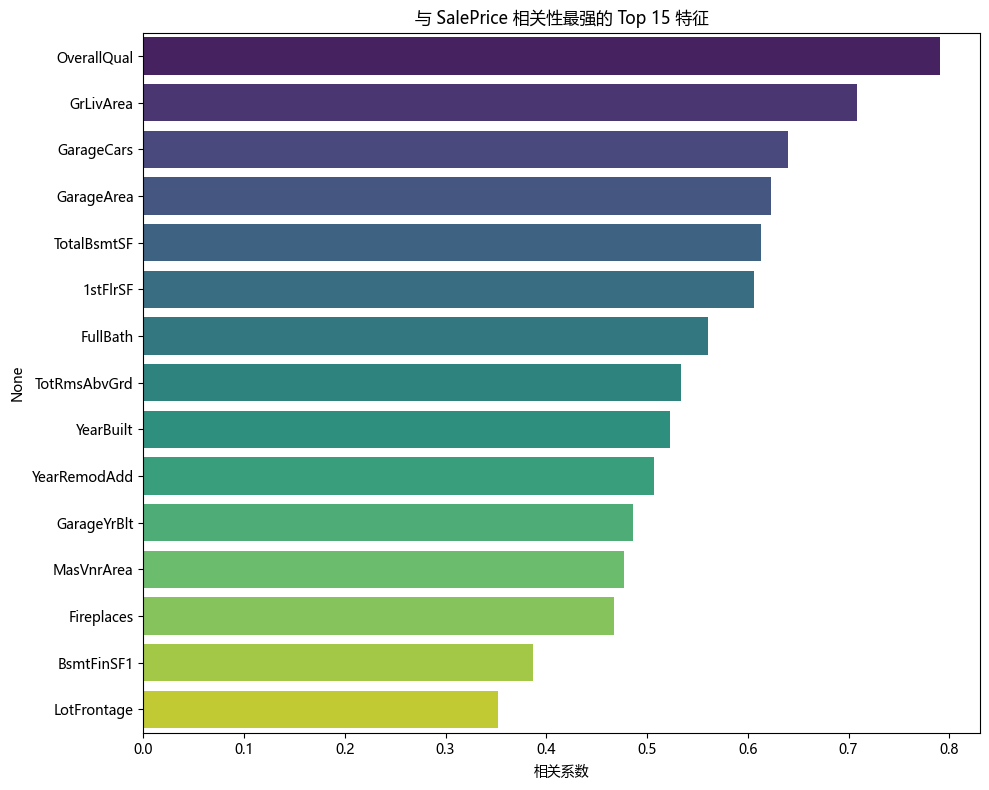

In [63]:
# ---- 数值特征与 SalePrice 的相关性（取 Top 15） ----
num_cols = train.select_dtypes(include=[np.number]).columns
corr = train[num_cols].corr()["SalePrice"].sort_values(ascending=False)
corr = corr.drop("SalePrice")

plt.figure(figsize=(10, 8))
sns.barplot(x=corr.values[:15], y=corr.index[:15], palette="viridis")
plt.title("与 SalePrice 相关性最强的 Top 15 特征")
plt.xlabel("相关系数")
plt.tight_layout()
plt.show()

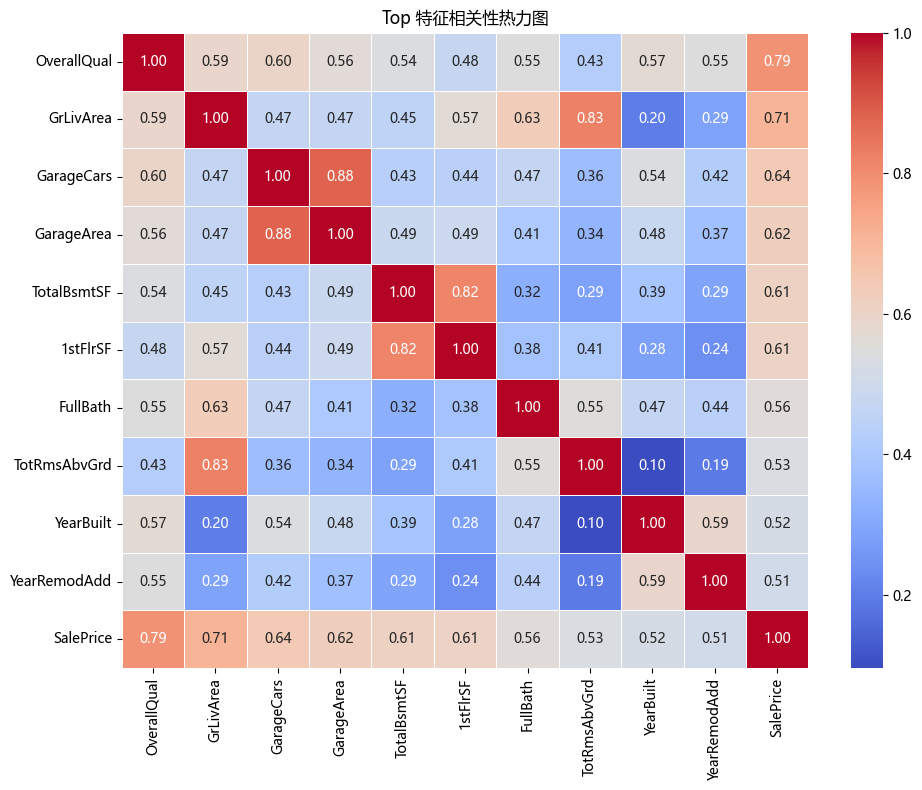

In [64]:
# ---- 数值特征两两相关性热力图（部分） ----
top_feats = corr.index[:10].tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(train[top_feats + ["SalePrice"]].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Top 特征相关性热力图")
plt.tight_layout()
plt.show()

很多高相关特征（如 TotalBsmtSF 与 1stFlrSF）→ 后续需用 VIF 检测多重共线性

## 4. 数据清洗与特征工程

In [65]:
def outlier_removal(df: pd.DataFrame) -> pd.DataFrame:
    """删除训练集的极端离群点（只作用于含 SalePrice 的训练集）。GrLivArea 很大但价格异常低的行是数据错误/极端值。"""
    # 规则：GrLivArea>4000 且 SalePrice<300000 视为离群点（只删这两类极端）
    cond = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)
    n = int(cond.sum())
    if n:
        print(f"  删除离群点 {n} 行: GrLivArea>4000 且 SalePrice<300000")
    return df.drop(df[cond].index)


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """对原始房价数据做统一的清洗与特征工程。"""
    df = df.copy()
    df = df.drop(columns=["Id"], errors="ignore")

    # ---------- 1) 去除严重异常值（只对训练集生效） ----------
    if "SalePrice" in df.columns:
        df = outlier_removal(df)

    # ---------- 2) 缺失值填充（先于派生特征，避免 NaN 扩散） ----------
    # 缺失本身有含义的类别特征 → "None"（代表没有该设施）
    none_fill = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
                 "GarageType", "GarageFinish", "GarageQual", "GarageCond",
                 "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
                 "MasVnrType", "Electrical", "KitchenQual", "Functional"]
    for c in none_fill:
        if c in df.columns:
            df[c] = df[c].fillna("None")

    # 数值缺失 → 填 0（代表无车库/无地下室等）
    zero_fill = ["GarageYrBlt", "GarageArea", "GarageCars",
                 "TotalBsmtSF", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
                 "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath",
                 "MasVnrArea", "LotFrontage"]
    for c in zero_fill:
        if c in df.columns:
            df[c] = df[c].fillna(0)

    # ---------- 3) 创造组合特征（此时各列已无缺失，计算安全） ----------
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["TotalBath"] = df["BsmtFullBath"] + df["FullBath"] + 0.5 * (df["BsmtHalfBath"] + df["HalfBath"])
    df["TotalPorchSF"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]

    # ---------- 4) 偏态数值特征做 log1p 变换 ----------
    skewed_features = [
        "LotArea", "GrLivArea", "1stFlrSF", "2ndFlrSF", "TotalBsmtSF",
        "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalSF",
        "OpenPorchSF", "EnclosedPorch", "ScreenPorch", "TotalPorchSF",
        "MiscVal", "PoolArea", "WoodDeckSF", "MasVnrArea",
    ]
    for c in skewed_features:
        if c in df.columns:
            df[c] = np.log1p(df[c].clip(lower=0))

    return df


In [66]:
# ---- 执行预处理 ----
train_proc = preprocess(train)
test_proc = preprocess(test)

print(f"清洗后训练集形状: {train_proc.shape}（删除异常值后）")
print(f"清洗后测试集形状: {test_proc.shape}")

# log1p 处理目标变量（模型预测时需用 expm1 还原）
y = np.log1p(train_proc["SalePrice"])
X_train = train_proc.drop(columns=["SalePrice"])
X_test = test_proc.copy()

print(f"\n目标变量用 log1p 变换：偏度从 {stats.skew(train['SalePrice']):.2f} 降到 {stats.skew(y):.2f} 以内（近似正态）")

  删除离群点 2 行: GrLivArea>4000 且 SalePrice<300000
清洗后训练集形状: (1458, 85)（删除异常值后）
清洗后测试集形状: (1459, 84)

目标变量用 log1p 变换：偏度从 1.88 降到 0.12 以内（近似正态）


检查清洗后的缺失值（应已全部处理）。

In [67]:
remaining_missing = X_train.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing) == 0:
    print("X_train 无缺失值")
else:
    print("X_train 仍有缺失:")
    print(remaining_missing)

remaining_missing_test = X_test.isnull().sum()
remaining_missing_test = remaining_missing_test[remaining_missing_test > 0]
if len(remaining_missing_test) == 0:
    print("X_test 无缺失值")
else:
    print("X_test 仍有缺失（交给 imputer 处理）:")
    print(remaining_missing_test)

X_train 无缺失值
X_test 仍有缺失（交给 imputer 处理）:
MSZoning       4
Utilities      2
Exterior1st    1
Exterior2nd    1
SaleType       1
dtype: int64


## 5. 多重共线性检测（VIF）

要点：线性回归对**多重共线性敏感**（系数不稳定、显著性失真）。我们先用 VIF 筛选高度共线的数值特征，再进入建模。

In [68]:
def compute_vif(df_num: pd.DataFrame, threshold: float = 10.0, protect: tuple = ()):
    """迭代式 VIF 消除（用 sklearn LinearRegression，稳健处理奇异矩阵）。

    每次剔除「VIF 最高且未被保护」的特征，然后重算，直到剩余特征
    全部低于阈值或无可剔除。

    返回: (保留特征名列表, 剔除特征名列表)
    """
    from sklearn.linear_model import LinearRegression

    remaining = list(df_num.columns)
    removed = []
    protect = set(protect)

    for _ in range(len(remaining)):
        X = df_num[remaining].values
        vifs = []
        for i in range(len(remaining)):
            col = X[:, i]
            rest = np.delete(X, i, axis=1)
            lr = LinearRegression()
            try:
                lr.fit(rest, col)
                r2 = lr.score(rest, col)
            except Exception:
                r2 = 1.0
            vif = 1.0 / (1.0 - r2) if r2 < 0.9999 else np.inf
            vifs.append(vif)

        # 找 VIF 最高且未被保护、且超阈值的特征
        order = sorted(range(len(remaining)), key=lambda j: -vifs[j])
        drop_idx = None
        for j in order:
            if remaining[j] in protect:
                continue
            if vifs[j] > threshold:
                drop_idx = j
                break
        if drop_idx is None:
            break

        removed.append(remaining[drop_idx])
        remaining.pop(drop_idx)

    return remaining, removed


In [69]:
# ---- 对数值特征做 VIF 检测（迭代消除，保护核心解释特征） ----
num_feats = X_train.select_dtypes(include=[np.number]).columns.tolist()

# 保护名单：公认的强特征，即使与其他特征相关也不剔除
PROTECT_FEATS = ["OverallQual", "YearBuilt", "GrLivArea", "LotArea"]

keep_feats, drop_feats = compute_vif(X_train[num_feats], threshold=10.0, protect=PROTECT_FEATS)
print("VIF 迭代消除完成")
print("保留的数值特征数:", len(keep_feats))
print("剔除的高共线特征:", drop_feats)

X_train = X_train.drop(columns=drop_feats, errors="ignore")
X_test = X_test.drop(columns=drop_feats, errors="ignore")
print(f"剔除后特征数: {X_train.shape[1]}")


VIF 迭代消除完成
保留的数值特征数: 35
剔除的高共线特征: ['YearRemodAdd', 'BsmtFullBath', 'YrSold', 'HouseAge', 'TotalSF', '2ndFlrSF']
剔除后特征数: 78


## 6. 模型构建与选择（线性 / 岭 / 套索）

要点：用 **Pipeline** 把「缺失值填充 → 独热编码 → 标准化」封装成一条链，训练/测试完全一致，避免数据泄漏。

In [70]:
def build_model(regressor):
    """构建统一的预处理 + 模型 Pipeline。"""
    num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),  # 数值缺失用中位数
                ("scaler", StandardScaler()),                    # 标准化，利于正则化收敛
            ]), num_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_features),
        ]
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor),
    ])


def cv_rmse(model, X, y, cv=5):
    """5 折交叉验证，返回 RMSE（在 log 空间，越小越好）。"""
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = -cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kf)
    return np.sqrt(scores), np.sqrt(scores).mean()

In [71]:
# ---- 三种模型对比（线性 / 岭 / 套索） ----
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.001, random_state=RANDOM_STATE),
}

results = {}
for name, reg in models.items():
    model = build_model(reg)
    fold_rmse, mean_rmse = cv_rmse(model, X_train, y)
    results[name] = mean_rmse
    print(f"{name:18s}  CV-RMSE(均值): {mean_rmse:.5f}   (各折: {np.round(fold_rmse, 5)})")

LinearRegression    CV-RMSE(均值): 0.13716   (各折: [0.14254 0.1767  0.12935 0.12934 0.10785])
Ridge               CV-RMSE(均值): 0.11705   (各折: [0.11745 0.12038 0.12214 0.1249  0.10036])
Lasso               CV-RMSE(均值): 0.11266   (各折: [0.11355 0.10736 0.12612 0.11687 0.09939])


In [72]:
# ---- 选出最佳模型并输出对比表格 ----
best_name = min(results, key=results.get)
pd.DataFrame(results.items(), columns=["模型", "CV-RMSE(log)"]).set_index("模型")

,CV-RMSE(log)
模型,
LinearRegression,0.1372
Ridge,0.1170
Lasso,0.1127


## 7. 模型评估

用最佳模型做**训练集残差诊断**，验证线性假设与过拟合情况。

In [73]:
# ---- 用最佳模型拟合训练集 ----
best_model = build_model(models[best_name])
best_model.fit(X_train, y)

train_pred_log = best_model.predict(X_train)

# 还原到原始价格空间评估
train_pred_price = np.expm1(train_pred_log)
train_true_price = np.expm1(y)

print(f"模型: {best_name}")
print(f"R²        : {r2_score(y, train_pred_log):.4f}")
print(f"RMSE(原始): {root_mean_squared_error(train_true_price, train_pred_price):.2f} $")
print(f"MAE(原始) : {mean_absolute_error(train_true_price, train_pred_price):.2f} $")

模型: Lasso
R²        : 0.9323
RMSE(原始): 20263.54 $
MAE(原始) : 13034.31 $


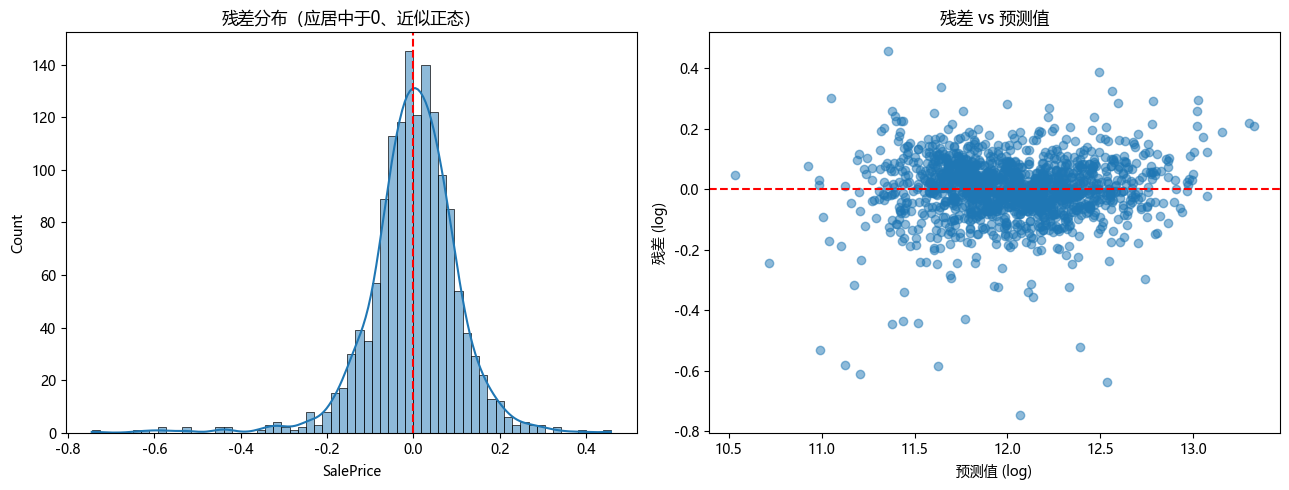

残差均值: -0.00000（越接近0越好）


In [74]:
# ---- 残差诊断图 ----
residuals = y - train_pred_log

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 残差直方图：应近似于均值为 0 的正态分布
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("残差分布（应居中于0、近似正态）")

# 残差 vs 预测值：不应呈现明显漏斗形（异方差）
axes[1].scatter(train_pred_log, residuals, alpha=0.5)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("预测值 (log)")
axes[1].set_ylabel("残差 (log)")
axes[1].set_title("残差 vs 预测值")
plt.tight_layout()
plt.show()

# 统计残差均值（理想接近0）
print(f"残差均值: {residuals.mean():.5f}（越接近0越好）")

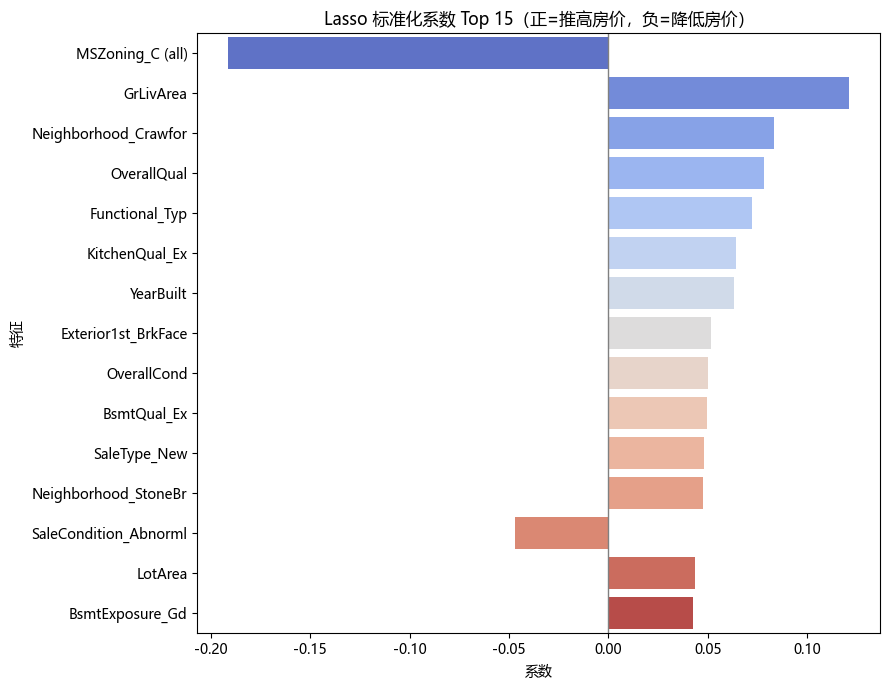

In [75]:
# ---- 特征重要性（通过标准化的回归系数绝对值） ----
# 要点：线性模型的系数大小体现特征对价格的影响强度。
transformer = best_model.named_steps["preprocessor"]
regressor = best_model.named_steps["regressor"]

encoded_feats = (
    transformer
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(transformer.transformers_[1][1].named_steps["imputer"].feature_names_in_)
)
num_feats = transformer.transformers_[0][1].named_steps["imputer"].feature_names_in_
all_feats = list(num_feats) + list(encoded_feats)

coef_df = pd.DataFrame({"特征": all_feats, "系数": regressor.coef_})
coef_df["|系数|"] = coef_df["系数"].abs()
top_coef = coef_df.sort_values("|系数|", ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_coef["系数"], y=top_coef["特征"], palette="coolwarm")
plt.title(f"{best_name} 标准化系数 Top 15（正=推高房价，负=降低房价）")
plt.axvline(0, color="gray", linestyle="-", linewidth=1)
plt.tight_layout()
plt.show()

## 8. 预测并生成提交文件

在测试集上预测（记得把 log 还原成真实房价），生成符合 Kaggle 提交格式的文件。

In [76]:
# ---- 预测测试集 ----
test_pred_log = best_model.predict(X_test)
test_pred_price = np.expm1(test_pred_log)  # log 还原

# 要点：价格不能为负，做下限保护
test_pred_price = np.maximum(test_pred_price, 0)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_pred_price,
})

submission.head()

,Id,SalePrice
0,1461,121459.6675
1,1462,152431.5671
2,1463,182528.8789
3,1464,201498.6379
4,1465,196233.7697


In [77]:
# ---- 保存提交文件（到数据目录内，避免污染仓库结构） ----
submission_path = os.path.join(DATA_DIR, "submission.csv")
submission.to_csv(submission_path, index=False)
print(f"已保存提交文件: {submission_path}")
print(f"提交行数: {len(submission)}（应与 sample_submission 一致 = {len(pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv')))}）")

已保存提交文件: house-prices-data\submission.csv
提交行数: 1459（应与 sample_submission 一致 = 1459）


In [78]:
# ---- 项目总结 ----
print("=" * 60)
print("House Prices 线性回归项目完成！")
print("=" * 60)
print(f"  最佳模型        : {best_name}")
print(f"  5折CV-RMSE(log) : {results[best_name]:.5f}")
print(f"  训练集 R²       : {r2_score(y, train_pred_log):.4f}")
print(f"  提交文件        : {submission_path}")
print("=" * 60)
print("下一步优化方向: 更精细特征工程、XGBoost/LightGBM 集成、超参数网格搜索")

House Prices 线性回归项目完成！
  最佳模型        : Lasso
  5折CV-RMSE(log) : 0.11266
  训练集 R²       : 0.9323
  提交文件        : house-prices-data\submission.csv
下一步优化方向: 更精细特征工程、XGBoost/LightGBM 集成、超参数网格搜索
